![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [8]:
# Celda 1.1
print(f"Media: {bikes.groupby('season').total.mean()}")
print(f"Desviación estándar: {bikes.groupby('season').total.std()}")
print(f"Valor mínimo: {bikes.groupby('season').total.min()}")
print(f"Mediana: {bikes.groupby('season').total.median()}")
print(f"Valor máximo: {bikes.groupby('season').total.max()}")


Media: season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64
Desviación estándar: season
1    125.273974
2    192.007843
3    197.151001
4    177.622409
Name: total, dtype: float64
Valor mínimo: season
1    1
2    1
3    1
4    1
Name: total, dtype: int64
Mediana: season
1     78.0
2    172.0
3    195.0
4    161.0
Name: total, dtype: float64
Valor máximo: season
1    801
2    873
3    977
4    948
Name: total, dtype: int64


La temporada tiene una influencia significativa en el numero de bicicletas alquiladas, alcanza su punto de mayor demanda en la temporada codificada como numero 3, que parece ser el verano, la temporada con menor demanda es la codificada como numero 1, que parece ser el invierno, la diferencia de medias entre las dos es de 72 bicicletas alquiladas, teniendo en cuenta que la media en la temporada 1 es de 125, esto representa un aumento del 57% en la demanda de bicicletas entre la temporada 1 y la temporada 3, lo que sugiere que la temporada es un factor importante a considerar al analizar el comportamiento de alquiler de bicicletas.

Una observacion interesante es que el numero maximo de bicicletas alquiladas, no se ve tan influenciado por la temporada, obteniendose valores relativamente cercanos entre las diferentes temporadas, lo que sugiere que aunque la temporada influye en la demanda promedio, no necesariamente limita el numero maximo de bicicletas alquiladas (¿debido al limite de bicicletas disponibles?)

Parece ser que la codificacion de la temporada es la siguiente: 1 = invierno, 2 = primavera, 3 = verano, 4 = otoño, acorde a su orden natural en el año, y si es asi, se observa un aumento progresivo en la demanda de bicicletas desde el invierno hasta el verano, seguido de una disminución en el otoño, lo que sugiere que las condiciones climáticas y la temperatura pueden estar influyendo en el comportamiento de alquiler de bicicletas

In [9]:
# Celda 1.2
print(f"Media: {bikes.groupby('hour').total.mean()}")
print(f"Desviación estándar: {bikes.groupby('hour').total.std()}")
print(f"Valor mínimo: {bikes.groupby('hour').total.min()}")
print(f"Mediana: {bikes.groupby('hour').total.median()}")
print(f"Valor máximo: {bikes.groupby('hour').total.max()}")

Media: hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64
Desviación estándar: hour
0      43.620012
1      34.112105
2      26.110267
3      12.666442
4       4.217633
5      12.784293
6      54.745333
7     159.207044
8     231.723065
9      92.099209
10    101.807629
11    127.444294
12    143.881880
13    149.167185
14    147.563199
15    144.235670
16    145.664786
17    223.775485
18    219.908138
19    156.641732
20    116.411565
21     87.629319
22     69.844495
23     51.638004
Name: total, dtype: float64
Valor mínimo: hour
0      2
1      1
2      1
3      1
4      1
5      1
6      1
7      1

En cuanto a la hora, como se esperaba, se observa un aumento progresivo en la demanda de bicicletas desde las primeras horas del día, alcanzando su punto máximo entre las 17 y 18 horas, tambien hay un pico alrededor de las 8 horas, lo que coincide con los horarios de entrada y salida del trabajo para muchas personas, seguido de una disminución progresiva durante la noche, lo que sugiere que el horario es un factor importante a considerar al analizar el comportamiento de alquiler de bicicletas

El numero de alquileres parece seguir los patrones de trafico que se observan en nuestro pais Colombia, incluso si los datos no proviene de la misma region


### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

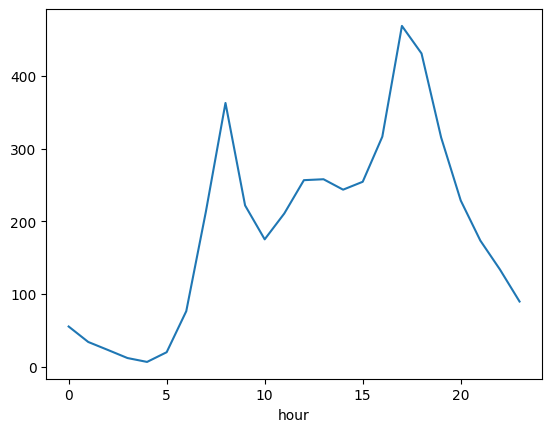

In [10]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

Como ya se habia mencionado en el punto anterior, el numero de alquileres a traves del dia sigue un patron que coincide con los horarios de entrada y salida del trabajo para muchas personas, alcanzando su punto máximo entre las 17 y 18 horas, y un segundo pico alrededor de las 8 horas

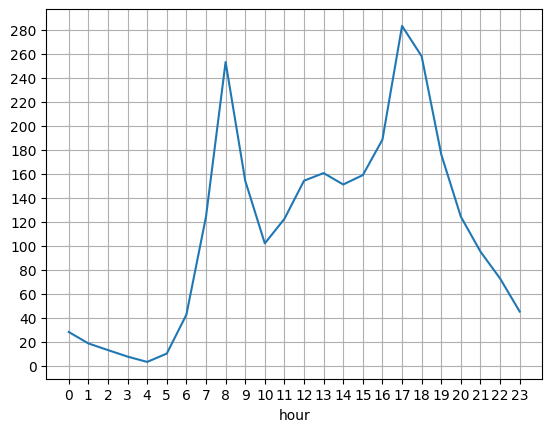

In [16]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
# add grid to the plot
import matplotlib.pyplot as plt
bikes[bikes.season==1].groupby('hour').total.mean().plot()
plt.xticks(range(0,24))
plt.yticks(range(0,300,20))
plt.grid()

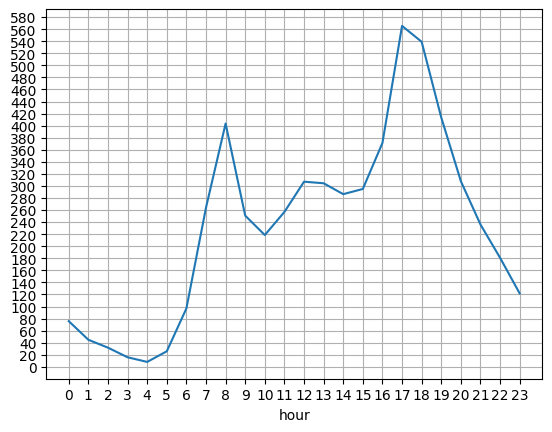

In [19]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos
bikes[bikes.season==3].groupby('hour').total.mean().plot()
plt.xticks(range(0,24))
plt.yticks(range(0,600,20))
plt.grid()


Las diferencias entre las temporadas 1 y 3 se mantienen a lo largo del dia, con la temporada 3 mostrando un numero de alquileres significativamente mayor en cada hora del dia, hay ciertas diferencias, una de ellas es que el pico de la tarde en la temporada 3 es mas pronunciado que en la temporada 1, otra diferencia es que la caida de alquileres en la hora 19 no es tan pronunciada en la temporada 3 como en la temporada 1. Se puede resumir es que la diferencia en el comportamiento de los alquileres a lo largo del dia entre las temporadas 1 y 3 es que la temporada 3 tiene un numero de alquileres significativamente mayor en cada hora del dia, con un pico de la tarde mas pronunciado y una caida menos pronunciada en la hora 19

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [35]:
# Celda 3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder


X = bikes[['season', 'hour']].copy()
y = bikes['total'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)


encoder = OneHotEncoder(sparse_output=False)
X_train_season_encoded = encoder.fit_transform(X_train[['season']])
X_train_encoded = pd.concat([
    pd.DataFrame(X_train_season_encoded, columns=encoder.get_feature_names_out()),
    pd.DataFrame(X_train['hour'].values, columns=['hour'])
], axis=1)

X_test_season_encoded = encoder.transform(X_test[['season']])
X_test_encoded = pd.concat([
    pd.DataFrame(X_test_season_encoded, columns=encoder.get_feature_names_out()),
    pd.DataFrame(X_test['hour'].values, columns=['hour'])
], axis=1)


lr = LinearRegression()
lr.fit(X_train_encoded, y_train)
print(f"R2 en el conjunto de entrenamiento: {lr.score(X_train_encoded, y_train)}")
print(f"MSE en el conjunto de entrenamiento: {np.mean((lr.predict(X_train_encoded) - y_train)**2)}")
print("----------------------------------------")
print(f"R2 en el conjunto de prueba: {lr.score(X_test_encoded, y_test)}")
print(f"MSE en el conjunto de prueba: {np.mean((lr.predict(X_test_encoded) - y_test)**2)}")
print("----------------------------------------")
print(f"Coeficientes del modelo: {[(X_train_encoded.columns[i], round(float(lr.coef_[i]), 2)) for i in range(len(lr.coef_))]}")


R2 en el conjunto de entrenamiento: 0.22160830576349566
MSE en el conjunto de entrenamiento: 25217.584774415205
----------------------------------------
R2 en el conjunto de prueba: 0.22541697003663597
MSE en el conjunto de prueba: 26125.777378491028
----------------------------------------
Coeficientes del modelo: [('season_1', -73.34), ('season_2', 20.56), ('season_3', 43.85), ('season_4', 8.93), ('hour', 10.59)]


In [27]:
X_train_encoded

,season_1,season_2,season_3,season_4,hour
0,0.0,0.0,1.0,0.0,6
1,1.0,0.0,0.0,0.0,17
2,0.0,0.0,1.0,0.0,2
3,0.0,1.0,0.0,0.0,17
4,0.0,1.0,0.0,0.0,3
...,...,...,...,...,...
7615,0.0,0.0,1.0,0.0,13
7616,0.0,1.0,0.0,0.0,22
7617,1.0,0.0,0.0,0.0,4
7618,0.0,0.0,0.0,1.0,10


### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [ ]:
# Celda 4


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [ ]:
# Celda 5


## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [ ]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

In [ ]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

In [ ]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [ ]:
# Celda 6


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [ ]:
# Celda 7


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [ ]:
# Celda 8


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [ ]:
# Celda 9